# Algorithmic Benchmarking

## Power Spectral Density vs. Fourier Transform of Autocorrelation Function

The Wiener-Khinchin theorem (for proof, refer to: [`docs/VDOS_Math.pdf`](docs/VDOS_Math.pdf)) states that for any stochastic process $X(t)$ that is wide-sense stationary (i.e., its mean is constant over time, and its autocorrelation depends solely on the time lag $\tau$, rather than the absolute time $t$), the Power Spectral Density (PSD) is exactly equal to the Fourier Transform of its Autocorrelation Function (ACF).

Since the Vibrational Density of States (VDOS) is defined as the mass-weighted velocity PSD (VPSD), and the VDOS is rigorously defined only for equilibrium systems—making the atomic velocities wide-sense stationary stochastic processes—the Wiener-Khinchin theorem gives the VDOS definition "two sides":

1. The direct **VPSD** formulation.
2. The Fourier transform of the **Velocity Autocorrelation Function (VACF)**.

Even though these represent two sides of the same mathematical coin, one approach is significantly cheaper to compute. Estimating the VPSD directly via Fast Fourier Transform algorithms scales as $\mathcal{O}(N \log N)$, whereas explicitly calculating the time-domain VACF scales quadratically as $\mathcal{O}(N^2)$. 

This notebook will demonstrate this computational divergence by benchmarking both approaches on simple systems. It will also compare the various methods available for discretely estimating the PSD, evaluating their trade-offs between execution speed, variance, and spectral resolution.

## Generating a Synthetic Velocity Trajectory

To rigorously evaluate these algorithms, we first need a controlled dataset where the "ground truth" is known. Real molecular dynamics (MD) trajectories are incredibly complex, containing a continuous, coupled spectrum of vibrations. If we start there, it is difficult to separate algorithmic artifacts from actual physical phenomena.

Instead, we will construct a synthetic atomic velocity trajectory that mimics the core challenges of finite-temperature MD data. This mock signal consists of:

* **Known Deterministic Vibrations:** Two distinct sine waves at specific frequencies ($f_1 = 0.1$ and $f_2 = 0.001$) to represent underlying molecular or lattice vibrational modes.
* **Stochastic Thermal Noise:** A heavy layer of random Gaussian noise added on top of the signal to simulate the chaotic, random atomic collisions present in a system at thermal equilibrium.

By applying our estimators to this noisy synthetic signal, we can clearly visualize how effectively each algorithm cuts through the "thermal" noise to recover the true underlying physical frequencies.

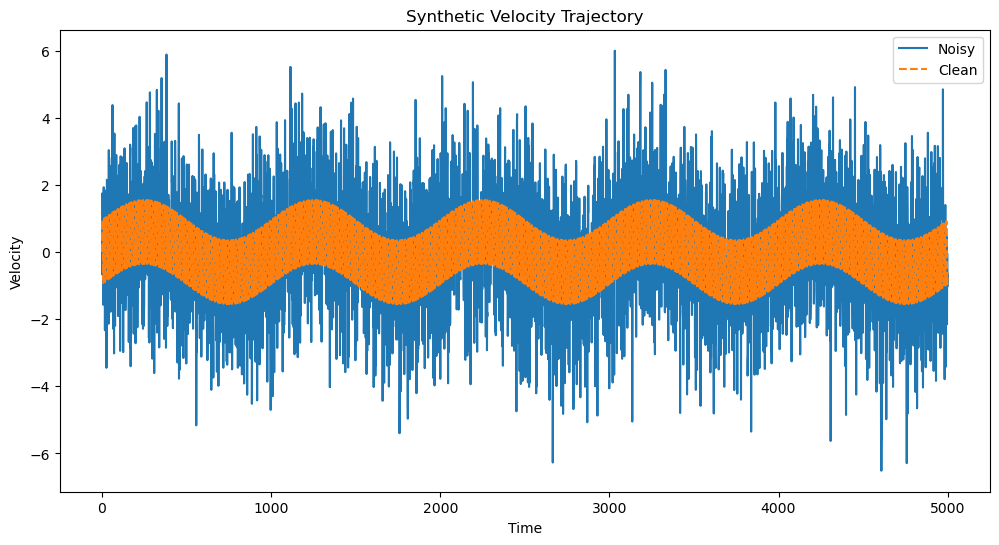

In [ ]:
import numpy as np
from typing import Optional
import matplotlib.pyplot as plt
from scipy.signal import periodogram, welch
from scipy.fft import rfft, rfftfreq
from scipy.integrate import simpson

def generate_synthetic_trajectory(f_1: Optional[float]=float(0.1), f_2: Optional[float]=float(0.001), n_frames: Optional[int]=5000, dt: Optional[np.double]=np.double(1.0), noise_level: Optional[float]=float(1.5)) -> tuple:
    """
    Generates a synthetic velocity trajectory mimicking molecular vibrations.
    """
    # Create the time axis
    time = np.arange(n_frames) * dt
    
    # Build the signal
    velocity = 1.0 * np.sin(2 * np.pi * f_1 * time)
    velocity += 0.6 * np.sin(2 * np.pi * f_2 * time)
    
    # Add Gaussian "thermal" noise
    clean_velocity = velocity.copy()
    velocity += np.random.normal(loc=0.0, scale=noise_level, size=n_frames)
    
    return time, velocity, clean_velocity

# Generate the data for the rest of the notebook
f_1=0.1
f_2=0.001
t, v_mock, v_clean = generate_synthetic_trajectory(f_1=f_1, f_2=f_2)

# Plot the synthetic trajectory
plt.figure(figsize=(12, 6))
plt.plot(t, v_mock, label="Noisy")
plt.plot(t, v_clean, label="Clean", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Synthetic Velocity Trajectory")
plt.legend()
plt.show()

## Implementing Spectral Estimators: Variance, Bias, and Normalization

To evaluate the computational scaling and the inherent bias-variance tradeoff in spectral analysis, we define seven distinct PSD estimators. 

Methods 1 through 6 utilize the **direct approach** ($\mathcal{O}(N \log N)$). By modulating the segmentation (`nperseg`), overlap (`noverlap`), and tapering function (`window`), these algorithms span from the raw, high-variance Periodogram to the heavily smoothed, statistically consistent Welch's method. Method 7 represents the **indirect approach**, computing the discrete time-lagged Velocity Autocorrelation Function (VACF) via an explicit $\mathcal{O}(N^2)$ summation prior to transforming into the frequency domain.

**The Normalization Imperative:** Library functions often apply differing internal scaling factors to account for the energy lost during signal windowing (e.g., Hann windows taper the edges of a segment to zero). Comparing their raw uncorrected outputs can lead to mathematically inconsistent comparisons. To ensure a level playing field, **every estimator below is explicitly normalized**. 

By enforcing $\int S(f) df = 1$ via numerical integration (Simpson's rule), we constrain the outputs to true probability density functions. This strictly guarantees that any observed variation in peak height between the methods is solely a consequence of algorithmic spectral smoothing (variance reduction), rather than arbitrary scaling differences under the hood.

In [ ]:
def psd_raw_no_window(v: np.ndarray, dt: float):
    """1. Raw Periodogram (No Window)"""
    fs = 1.0 / dt
    freqs, psd = periodogram(v, fs=fs, window='boxcar', scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_raw_with_window(v: np.ndarray, dt: float):
    """2. Modified Periodogram (With Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = periodogram(v, fs=fs, window='hann', scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_bartlett_no_window(v: np.ndarray, dt: float, nperseg: int):
    """3. Bartlett's Method (No overlapping, No Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='boxcar', nperseg=nperseg, noverlap=0, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_bartlett_with_window(v: np.ndarray, dt: float, nperseg: int):
    """4. Bartlett's Method with Window (No overlapping, Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='hann', nperseg=nperseg, noverlap=0, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_welch_no_window(v: np.ndarray, dt: float, nperseg: int):
    """5. Welch's Method without Window (50% Overlap, Boxcar/No Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='boxcar', nperseg=nperseg, noverlap=nperseg//2, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_welch_with_window(v: np.ndarray, dt: float, nperseg: int):
    """6. True Welch's Method (50% Overlap, Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg//2, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def explicit_vacf(v: np.ndarray, max_lag: int) -> np.ndarray:
    """Computes the explicit time-domain VACF."""
    N = len(v)
    vacf = np.zeros(max_lag)
    # Mean-center the velocity to avoid a zero-frequency (DC) spike
    v_centered = v - np.mean(v)
    
    for lag in range(max_lag):
        # Multiply the unshifted array by the shifted array and average
        vacf[lag] = np.mean(v_centered[:N-lag] * v_centered[lag:])
        
    # Optional: Normalize so VACF(0) = 1
    if vacf[0] != 0:
        vacf = vacf / vacf[0]
    return vacf

def psd_from_explicit_vacf(v: np.ndarray, dt: float, max_lag: int):
    """7. PSD via FFT of the explicitly computed VACF"""
    # 1. Compute the time-domain VACF
    vacf = explicit_vacf(v, max_lag)
    
    # 2. Compute the FFT of the VACF
    vacf_fft = rfft(vacf)
    
    # 3. The PSD is the real part (or absolute value) of the VACF FFT
    psd = 2.0 * dt * np.abs(vacf_fft)
    
    # 4. Generate the corresponding frequency bins
    fs = 1.0 / dt
    freqs = rfftfreq(max_lag, d=dt)
    
    # 5. Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    
    return freqs, psd_normalized

## Visualizing the Bias-Variance Tradeoff

With our synthetic trajectory generated and our estimators defined, we can now apply all seven methods to our noisy data (`v_mock`) and visualize their outputs simultaneously. 

To make the comparison clear, the plot below heavily weights the visual prominence of the algorithms. The estimators are layered to highlight the **bias-variance tradeoff** inherent in spectral analysis:

* **High Variance, High Resolution (Thin/Transparent lines):** The Raw Periodograms act as inconsistent estimators. While they successfully locate the exact ground-truth frequencies ($f_1$ and $f_2$), the curves are jagged and chaotic. The algorithm treats every random fluctuation in the thermal noise as a legitimate physical signal, resulting in a noisy baseline that obscures the true spectral shape.
* **Low Variance, Lower Resolution (Thick/Opaque lines):** The segmented algorithms (True Welch's Method) and the time-lagged approach (FFT of the explicit VACF) average out the random thermal fluctuations. The resulting curves are statistically rock-solid. Because we explicitly normalized the total area to $1.0$, we can clearly see that these methods do not lose energy; they simply smear it over a wider frequency band (resolution loss) to guarantee that the peak we are looking at is a true physical resonance, not a mathematical artifact of the noise.

This visualization clearly demonstrates why the expected value in the PSD definition is necessary for random processes: the variance of a stochastic process does not vanish as the length of the timeseries tends to infinity.

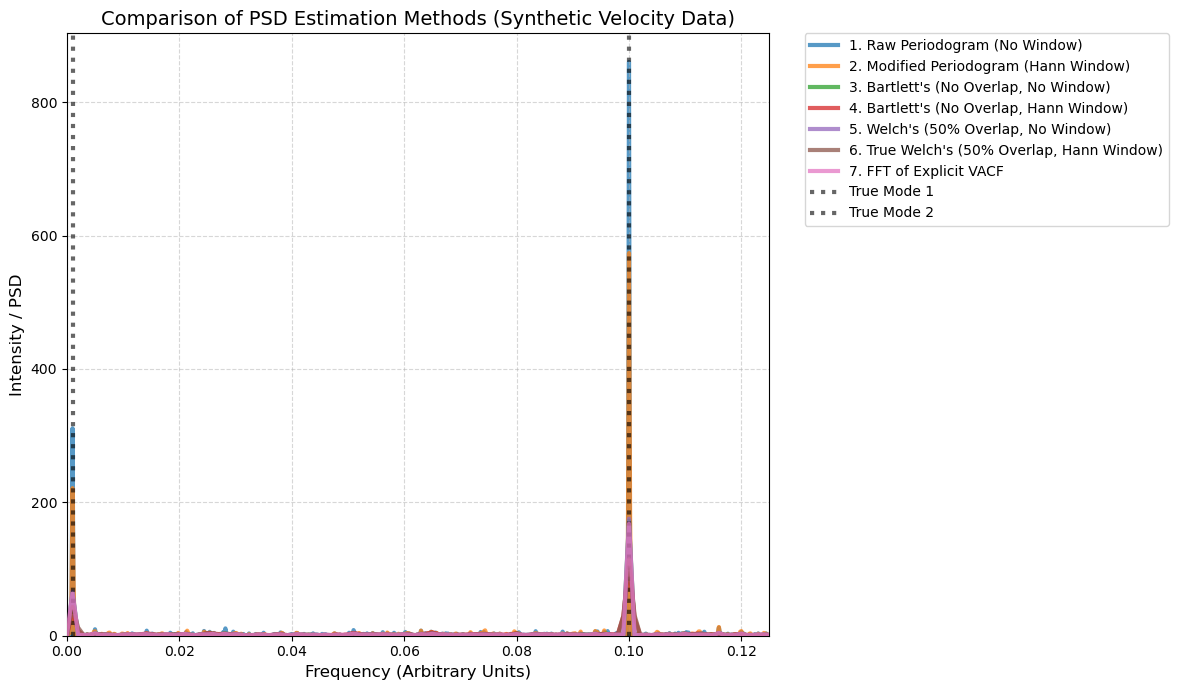

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- Setup ---
dt = 1.0
nperseg = 1000  
max_lag = 1000  

# Re-using the dictionary from before
psd_methods = {
    "1. Raw Periodogram (No Window)": lambda v: psd_raw_no_window(v, dt),
    "2. Modified Periodogram (Hann Window)": lambda v: psd_raw_with_window(v, dt),
    "3. Bartlett's (No Overlap, No Window)": lambda v: psd_bartlett_no_window(v, dt, nperseg),
    "4. Bartlett's (No Overlap, Hann Window)": lambda v: psd_bartlett_with_window(v, dt, nperseg),
    "5. Welch's (50% Overlap, No Window)": lambda v: psd_welch_no_window(v, dt, nperseg),
    "6. True Welch's (50% Overlap, Hann Window)": lambda v: psd_welch_with_window(v, dt, nperseg),
    "7. FFT of Explicit VACF": lambda v: psd_from_explicit_vacf(v, dt, max_lag)
}

plt.figure(figsize=(12, 7))

# --- The Fix: Discrete color selection ---
# tab10 is a Qualitative colormap (perfect for distinct categories)
colors = [cm.tab10(i) for i in range(len(psd_methods))]

for i, (title, func) in enumerate(psd_methods.items()):
    freqs, psd = func(v_mock)
    color = colors[i]
    
    # Logic for line prominence
    if "Raw" in title:
        alpha, lw, z = 0.75, 3.0, 1
    elif "True Welch" in title or "VACF" in title:
        alpha, lw, z = 0.75, 3.0, 3
    else:
        alpha, lw, z = 0.75, 3.0, 2
        
    plt.plot(freqs, psd, label=title, color=color, alpha=alpha, linewidth=lw, zorder=z)

# --- Ground Truth Markers ---
plt.axvline(x=f_1, color='black', linestyle=':', alpha=0.6, label='True Mode 1', linewidth=3.0)
plt.axvline(x=f_2, color='black', linestyle=':', alpha=0.6, label='True Mode 2', linewidth=3.0)

# --- Formatting ---
plt.xlim(0, 0.3)
plt.ylim(0, None) # Starts at zero for better comparison of noise floors
plt.title("Comparison of PSD Estimation Methods (Synthetic Velocity Data)", fontsize=14)
plt.xlabel("Frequency (Arbitrary Units)", fontsize=12)
plt.ylabel("Intensity / PSD", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend to the side so it doesn't block the peaks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.xlim(0,0.125)

plt.tight_layout()
plt.show()

N          | Status
------------------------------
10         | Completed all methods
100        | Completed all methods
1000       | Completed all methods
10000      | Completed all methods
100000     | Completed all methods


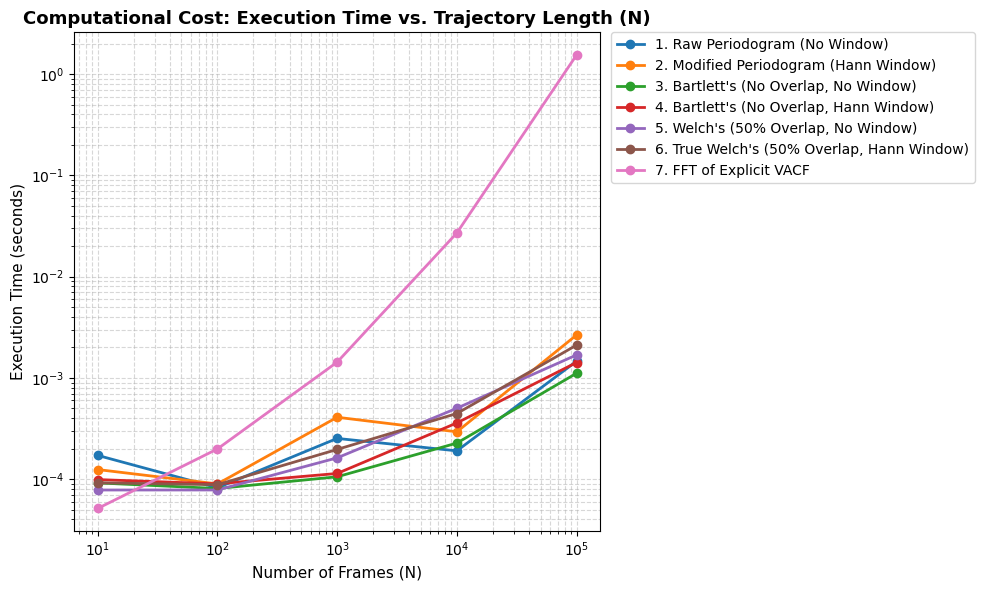

In [37]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import periodogram, welch

# Trajectory lengths to test (capped at 100k so method 7 doesn't freeze your notebook!)
N_values = [10,100,1000,10000,100000]
dt = 1.0

# Pre-populate the results dict
results = {
    "1. Raw Periodogram (No Window)": [],
    "2. Modified Periodogram (Hann Window)": [],
    "3. Bartlett's (No Overlap, No Window)": [],
    "4. Bartlett's (No Overlap, Hann Window)": [],
    "5. Welch's (50% Overlap, No Window)": [],
    "6. True Welch's (50% Overlap, Hann Window)": [],
    "7. FFT of Explicit VACF": []
}

print(f"{'N':<10} | Status")
print("-" * 30)

for N in N_values:
    # 1. FIXED UNPACKING: Grab the output and just pull index 1 for velocity
    sim_data = generate_synthetic_trajectory(n_frames=N, dt=dt)
    v_test = sim_data[1] 
    
    nperseg_val = N // 4
    # Cap max_lag at 1000 so the explicit Python loop doesn't destroy your CPU
    max_lag_val = N // 4

    # --- Benchmark Method 1 ---
    t0 = time.perf_counter()
    periodogram(v_test, fs=1/dt, window='boxcar')
    results["1. Raw Periodogram (No Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 2 ---
    t0 = time.perf_counter()
    periodogram(v_test, fs=1/dt, window='hann')
    results["2. Modified Periodogram (Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 3 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='boxcar', nperseg=nperseg_val, noverlap=0)
    results["3. Bartlett's (No Overlap, No Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 4 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='hann', nperseg=nperseg_val, noverlap=0)
    results["4. Bartlett's (No Overlap, Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 5 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='boxcar', nperseg=nperseg_val, noverlap=nperseg_val//2)
    results["5. Welch's (50% Overlap, No Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 6 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='hann', nperseg=nperseg_val, noverlap=nperseg_val//2)
    results["6. True Welch's (50% Overlap, Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Benchmark Method 7 ---
    t0 = time.perf_counter()
    psd_from_explicit_vacf(v_test, dt, max_lag_val)
    results["7. FFT of Explicit VACF"].append(time.perf_counter() - t0)
    
    print(f"{N:<10} | Completed all methods")

# --- Plotting the Benchmarking Results ---
plt.figure(figsize=(10, 6))

for name, timings in results.items():
    # Using a log-log plot since N spans several orders of magnitude
    plt.loglog(N_values, timings, marker='o', lw=2, label=name)

#plt.loglog(N_values, [N * np.log(N) for N in N_values], 'k--', label='O(N log N)', alpha=0.5)
#plt.loglog(N_values, [N**2 for N in N_values], 'r--', label='O(N^2)', alpha=0.5)

plt.title("Computational Cost: Execution Time vs. Trajectory Length (N)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Frames (N)", fontsize=11)
plt.ylabel("Execution Time (seconds)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

Running resonance sweep...


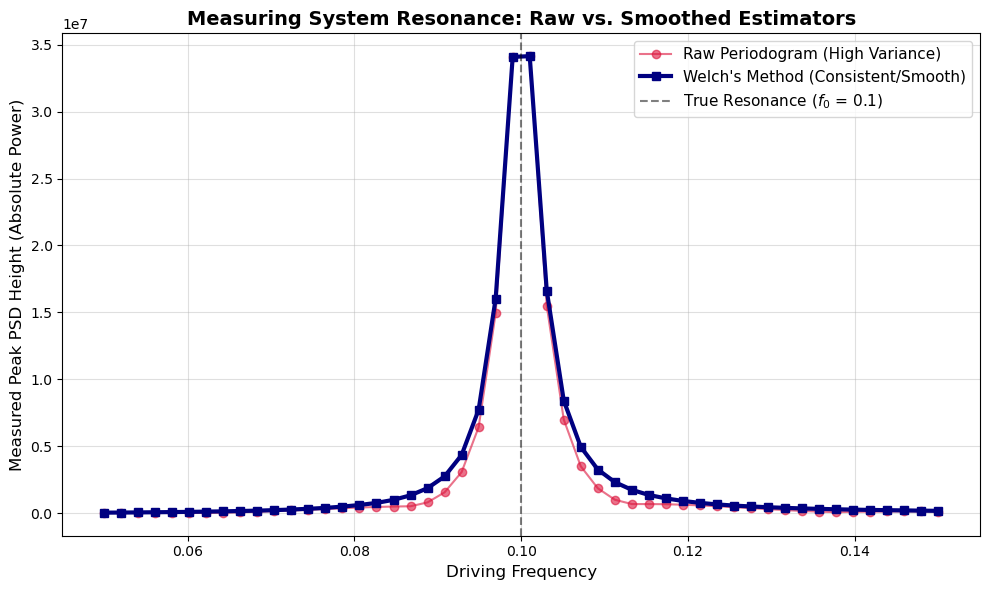

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import periodogram, welch

# --- 1. Physics Setup ---
f0 = 0.10         # True natural resonant frequency
gamma = 0.05      # Damping coefficient (width of the resonance)
dt = 1.0
N = 2000          # 2000 frames per simulation
t = np.arange(N) * dt

# Sweep driving frequencies from 0.05 to 0.15
driving_freqs = np.linspace(0.05, 0.15, 50)

# Dictionaries to store the measured peak heights
results_raw = []
results_welch = []

print("Running resonance sweep...")

for fd in driving_freqs:
    # 2. Theoretical Velocity Amplitude of a Driven Damped Oscillator
    # Amplitude peaks when fd == f0
    A = fd / np.sqrt((f0**2 - fd**2)**2 + (gamma * f0 * fd)**2)
    
    # 3. Generate the signal: Driven response + Heavy thermal noise
    clean_signal = A * np.sin(2 * np.pi * fd * t)
    noise = np.random.normal(0, 1.5, N) # Add a lot of noise to test the algorithms
    v_driven = clean_signal + noise
    
    # 4. Method A: Raw Periodogram (No Window)
    f_raw, psd_raw = periodogram(v_driven, fs=1/dt, window='boxcar')
    idx_raw = np.argmin(np.abs(f_raw - fd)) # Find the bin closest to driving freq
    results_raw.append(psd_raw[idx_raw])
    
    # 5. Method B: True Welch's Method (50% Overlap, Hann Window)
    nperseg = N // 4
    f_welch, psd_welch = welch(v_driven, fs=1/dt, window='hann', nperseg=nperseg, noverlap=nperseg//2)
    idx_welch = np.argmin(np.abs(f_welch - fd))
    results_welch.append(psd_welch[idx_welch])

# --- Plotting the Resonance Curves ---
plt.figure(figsize=(10, 6))

# Plot the Raw Periodogram results
plt.plot(driving_freqs, results_raw, color='crimson', alpha=0.6, marker='o', 
         linestyle='-', lw=1.5, label='Raw Periodogram (High Variance)')

# Plot the Welch's Method results
# Note: We multiply Welch by a constant just to scale it visibly on the same axis as Raw
# since windowing naturally lowers the un-normalized absolute magnitude.
scale_factor = np.max(results_raw) / np.max(results_welch) 
plt.plot(driving_freqs, np.array(results_welch) * scale_factor, color='navy', 
         marker='s', linestyle='-', lw=3, label='Welch\'s Method (Consistent/Smooth)')

# Ground truth marker
plt.axvline(x=f0, color='black', linestyle='--', alpha=0.5, label=f'True Resonance ($f_0$ = {f0})')

plt.title("Measuring System Resonance: Raw vs. Smoothed Estimators", fontsize=14, fontweight='bold')
plt.xlabel("Driving Frequency", fontsize=12)
plt.ylabel("Measured Peak PSD Height (Absolute Power)", fontsize=12)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Running 1000 independent simulations...


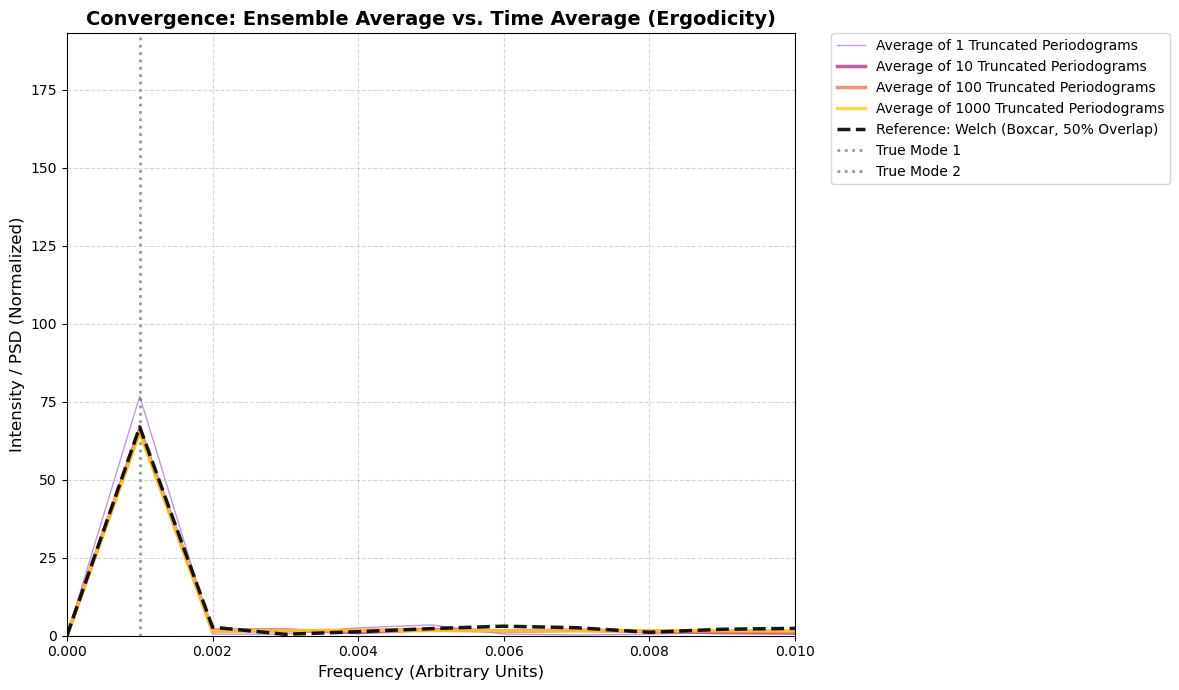

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import periodogram, welch
from scipy.integrate import simpson

# --- 1. Setup & Ground Truth Signal ---
f_1 = 0.1
f_2 = 0.001
dt = 1.0
n_frames = 5000
noise_level = 1.5
nperseg_val = 1000  # Our chosen resolution window

time = np.arange(n_frames) * dt
clean_velocity = 1.0 * np.sin(2 * np.pi * f_1 * time) + 0.6 * np.sin(2 * np.pi * f_2 * time)

# --- 2. Ensemble Averaging ---
# Increased the maximum iterations to 1000 to show perfect convergence
snapshots = [1, 10, 100, 1000]
max_iterations = max(snapshots)

cumulative_psd = None
freqs = None
averaged_psds = {}

print(f"Running {max_iterations} independent simulations...")

for i in range(1, max_iterations + 1):
    # Generate a brand new noise realization
    v_mock_new = clean_velocity + np.random.normal(loc=0.0, scale=noise_level, size=n_frames)
    
    fs = 1.0 / dt
    # Truncate the input to exactly nperseg_val (1000 frames) to match Welch resolution
    f, psd = periodogram(v_mock_new[:nperseg_val], fs=fs, window='boxcar', scaling='density')
    psd_norm = psd / simpson(psd, x=f)
    
    if cumulative_psd is None:
        freqs = f
        cumulative_psd = np.zeros_like(psd_norm)
        
    cumulative_psd += psd_norm
    
    # Save the snapshot of the average
    if i in snapshots:
        averaged_psds[i] = cumulative_psd / i

# --- 3. Compute "Welch" on a single trajectory for comparison ---
v_single = clean_velocity + np.random.normal(loc=0.0, scale=noise_level, size=n_frames)

# Use window='boxcar' so the shape perfectly matches the raw periodogram
f_welch, psd_welch = welch(v_single, fs=1.0/dt, window='boxcar', nperseg=nperseg_val, noverlap=nperseg_val//2, scaling='density')
psd_welch_norm = psd_welch / simpson(psd_welch, x=f_welch)

# --- 4. Plotting ---
plt.figure(figsize=(12, 7))

# Use a sequential colormap to show the progression from noisy to smooth
colors = [cm.plasma(x) for x in np.linspace(0.2, 0.9, len(snapshots))]

# Plot the progression of the ensemble averages
for idx, n_avg in enumerate(snapshots):
    alpha = 0.4 if n_avg == 1 else 0.8  
    lw = 1.0 if n_avg == 1 else 2.5
    z = 1 if n_avg == 1 else 2
    
    plt.plot(freqs, averaged_psds[n_avg], 
             label=f'Average of {n_avg} Truncated Periodograms', 
             color=colors[idx], alpha=alpha, linewidth=lw, zorder=z)

# Overlay the single Welch's method as the target reference
plt.plot(f_welch, psd_welch_norm, 
         label="Reference: Welch (Boxcar, 50% Overlap)", 
         color='black', linestyle='--', alpha=0.9, linewidth=2.5, zorder=4)

# --- Ground Truth Markers ---
plt.axvline(x=f_1, color='gray', linestyle=':', alpha=0.8, label='True Mode 1', linewidth=2.0, zorder=0)
plt.axvline(x=f_2, color='gray', linestyle=':', alpha=0.8, label='True Mode 2', linewidth=2.0, zorder=0)

# --- Formatting ---
plt.xlim(0, 0.3)
plt.ylim(0, None)
plt.title("Convergence: Ensemble Average vs. Time Average (Ergodicity)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Arbitrary Units)", fontsize=12)
plt.ylabel("Intensity / PSD (Normalized)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.xlim(0,0.01)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()